In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, classification_report, precision_score, r2_score, f1_score, accuracy_score, recall_score, roc_auc_score, roc_curve

In [2]:
df = pd.read_csv('loan_risk_prediction_dataset.csv')
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


### EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [4]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [5]:
df.shape

(5000, 10)

In [6]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print(df['Education'].value_counts())
print()
print(df['City'].value_counts())
print()
print(df['EmploymentType'].value_counts())
print()
print(df['LoanApproved'].value_counts())

Education
Bachelors      1220
PhD            1199
Masters        1198
High School    1185
Name: count, dtype: int64

City
Chicago          1304
San Francisco    1257
Houston          1232
New York         1207
Name: count, dtype: int64

EmploymentType
Self-Employed    1730
Unemployed       1660
Salaried         1610
Name: count, dtype: int64

LoanApproved
0    3849
1    1151
Name: count, dtype: int64


In [9]:
numeric_data = df.select_dtypes(include=['int64','float64']).columns.drop('LoanApproved')
categorical_data = df.select_dtypes(include=['object']).columns

In [10]:
print(numeric_data)
print()
print(categorical_data)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience'], dtype='object')

Index(['Gender', 'Education', 'City', 'EmploymentType'], dtype='object')


In [11]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [12]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

## EDA on Numeric Data

In [13]:
df[numeric_data].skew()

Age               -0.012230
Income             0.006787
LoanAmount        -0.000293
CreditScore       -0.025602
YearsExperience   -0.004631
dtype: float64

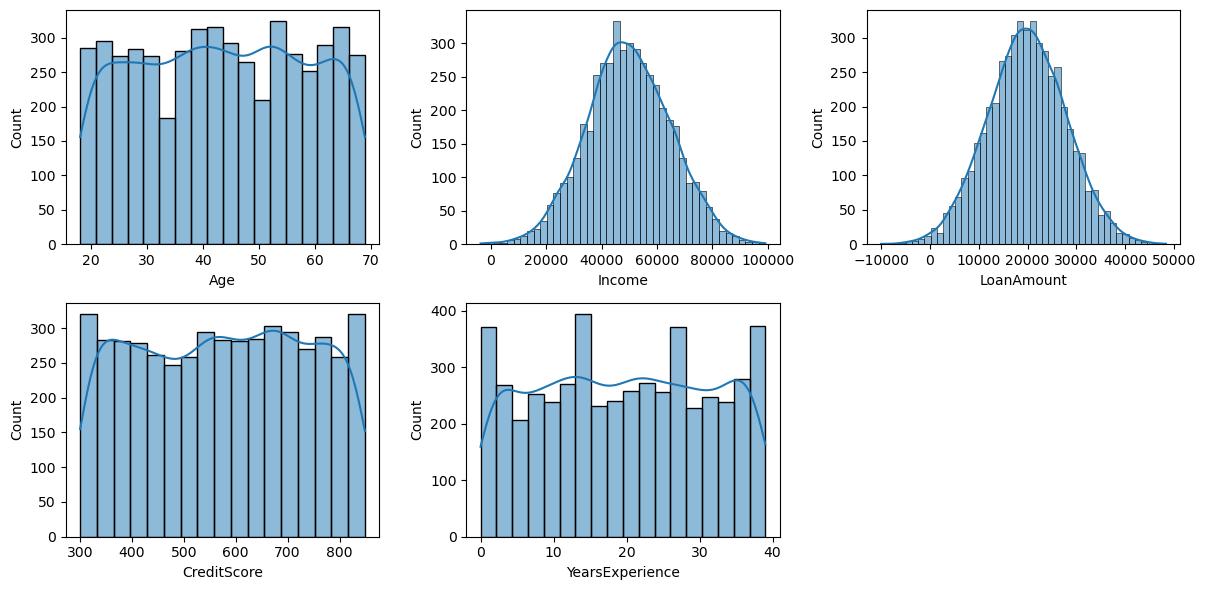

In [14]:
plt.figure(figsize=(12,6))
plt.subplot(231)
sns.histplot(df['Age'],kde=True)

plt.subplot(232)
sns.histplot(df['Income'],kde=True)

plt.subplot(233)
sns.histplot(df['LoanAmount'],kde=True)

plt.subplot(234)
sns.histplot(df['CreditScore'],kde=True)

plt.subplot(235)
sns.histplot(df['YearsExperience'],kde=True)

plt.tight_layout()
plt.show()

## Q-Q plot

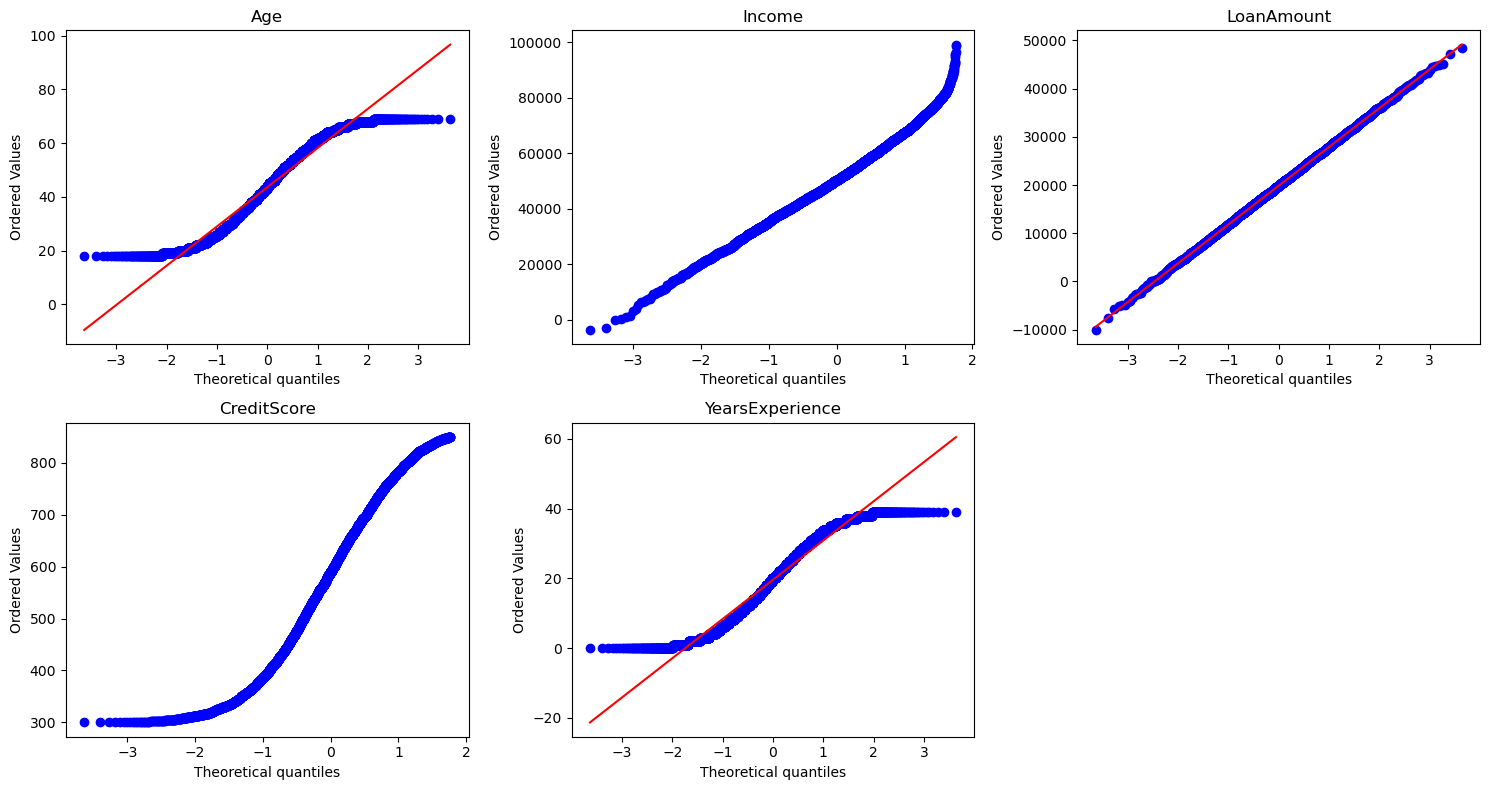

In [15]:
row = 2
column = 3

plt.figure(figsize=(15,8))
for i,cols in enumerate(numeric_data,1):
    plt.subplot(row, column, i)
    stats.probplot(df[cols], dist = 'norm', plot= plt)
    plt.title(cols)

plt.tight_layout()  
plt.show()

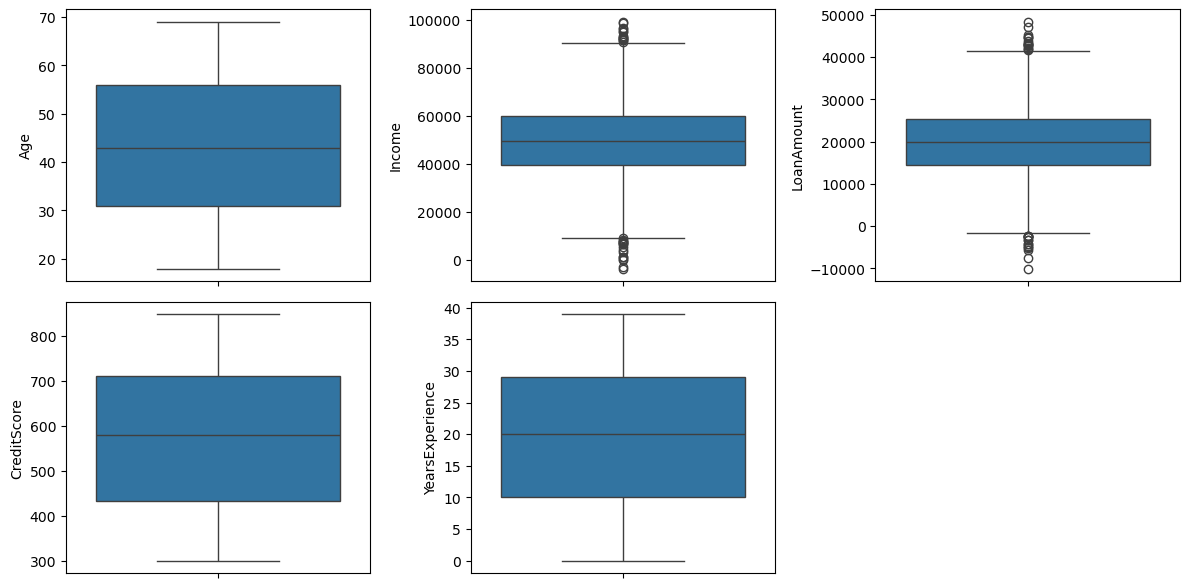

In [16]:
plt.figure(figsize=(12,6))
plt.subplot(231)
sns.boxplot(df['Age'])

plt.subplot(232)
sns.boxplot(df['Income'])

plt.subplot(233)
sns.boxplot(df['LoanAmount'])

plt.subplot(234)
sns.boxplot(df['CreditScore'])

plt.subplot(235)
sns.boxplot(df['YearsExperience'])

plt.tight_layout()
plt.show()

<Axes: >

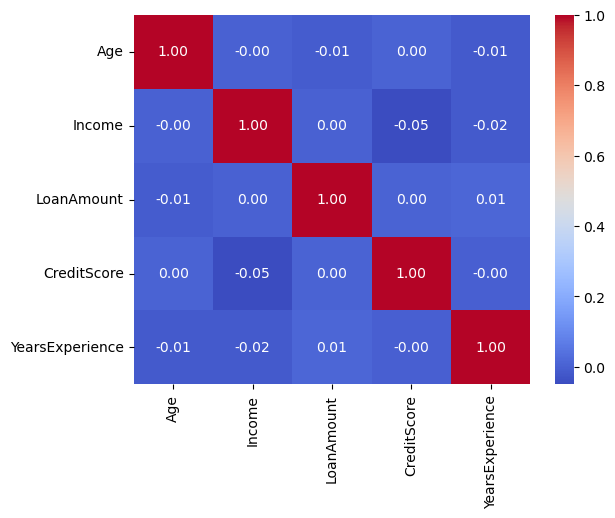

In [17]:
sns.heatmap(df[numeric_data].corr(), annot=True, fmt='.2f',cmap = 'coolwarm')

### EDA on Categorical variable

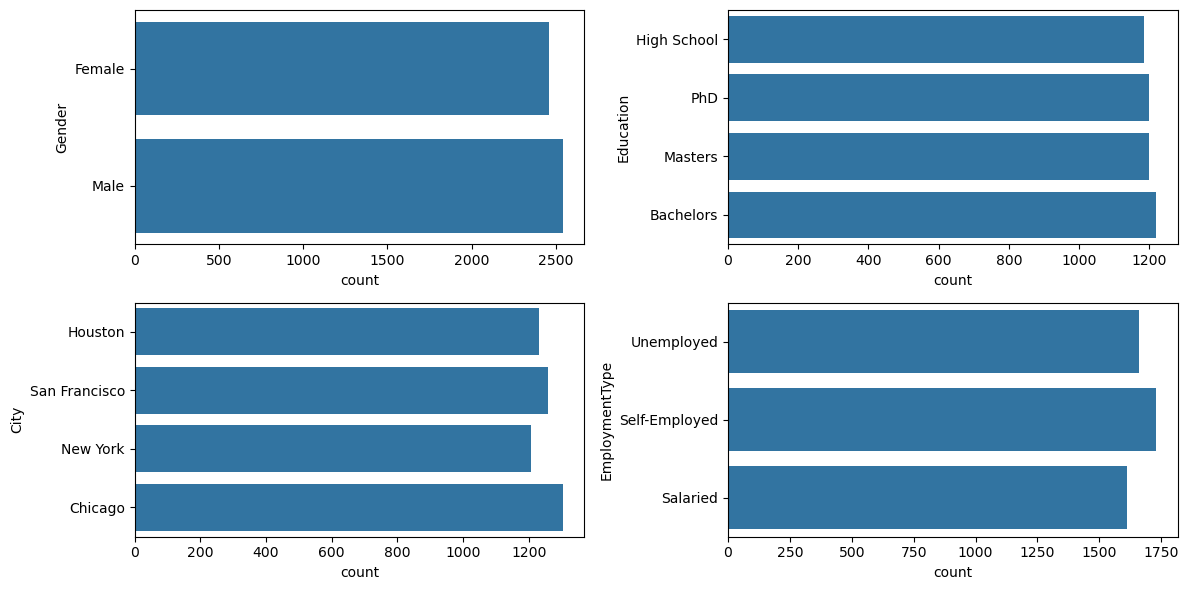

In [18]:
plt.figure(figsize=(12,6))
plt.subplot(221)
sns.countplot(df['Gender'])

plt.subplot(222)
sns.countplot(df['Education'])

plt.subplot(223)
sns.countplot(df['City'])

plt.subplot(224)
sns.countplot(df['EmploymentType'])


plt.tight_layout()
plt.show()

### EDA on Target variable, categorical variable and numeric variable

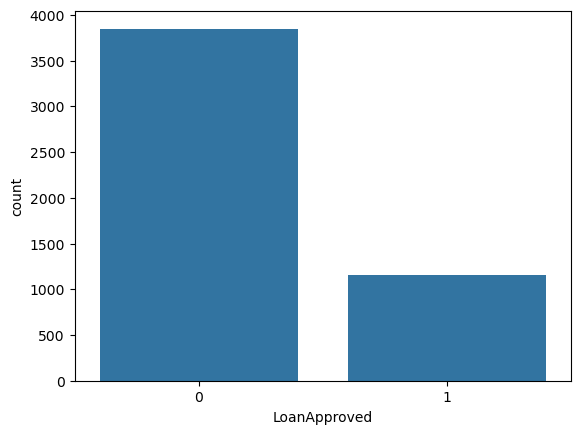

In [19]:
sns.countplot(x = df['LoanApproved'])
plt.show()

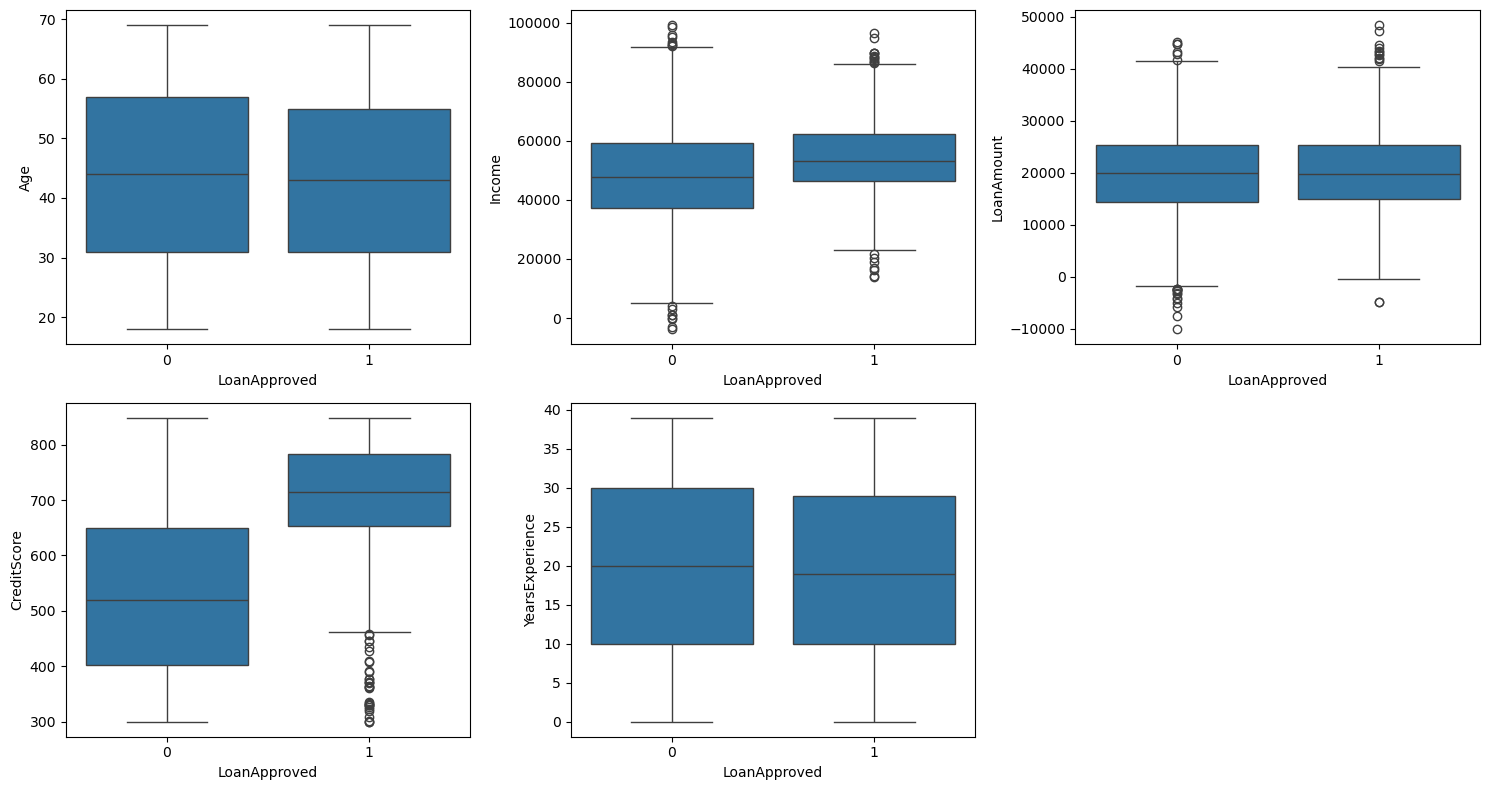

In [20]:
plt.figure(figsize=(15,8))
for i, cols in enumerate(numeric_data, 1):
    plt.subplot(2,3, i)
    sns.boxplot(x = df['LoanApproved'], y = df[cols])
plt.tight_layout()    
plt.show()

In [21]:
df.groupby('LoanApproved')[numeric_data].mean()

,Age,Income,LoanAmount,CreditScore,YearsExperience
LoanApproved,,,,,
0,43.656015,48164.507971,19790.243959,533.718776,19.639127
1,43.345786,55018.222121,20140.046916,708.761988,19.464813


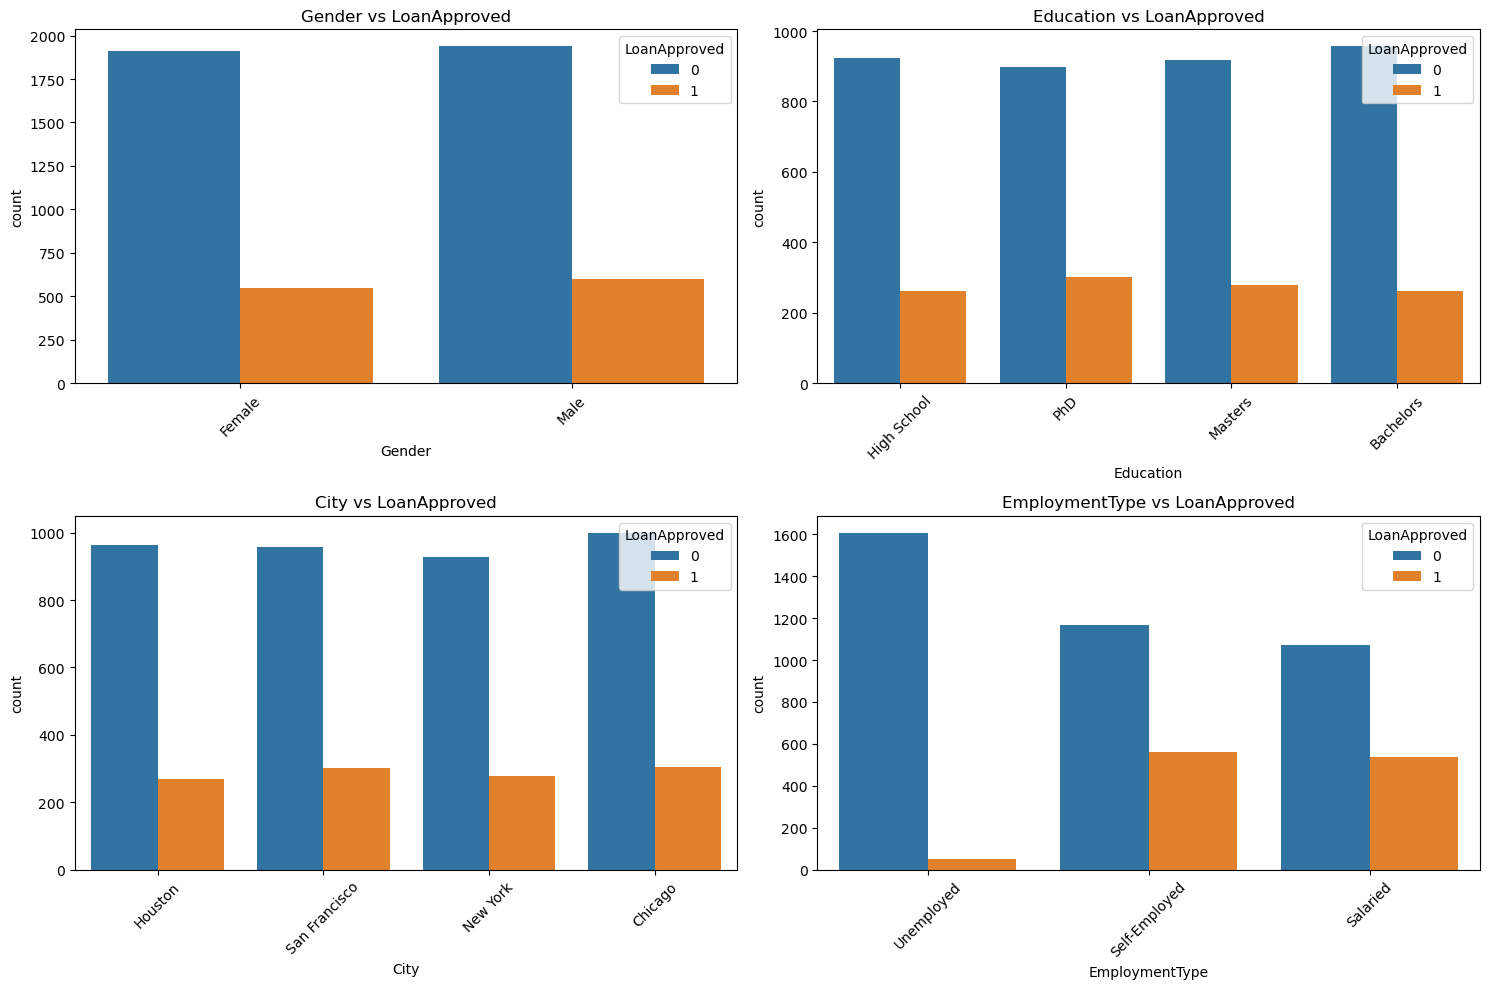

In [22]:
plt.figure(figsize=(15,10))

for i, col in enumerate(categorical_data, 1):
    plt.subplot(2,2,i)
    sns.countplot(x=col, hue='LoanApproved', data=df)
    plt.title(f"{col} vs LoanApproved")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
for col in categorical_data:
    print(f"\n{col} vs LoanApproved (%)")
    print(pd.crosstab(df[col], df['LoanApproved'], normalize='index') * 100)


Gender vs LoanApproved (%)
LoanApproved          0          1
Gender                            
Female        77.673851  22.326149
Male          76.308540  23.691460

Education vs LoanApproved (%)
LoanApproved          0          1
Education                         
Bachelors     78.442623  21.557377
High School   77.974684  22.025316
Masters       76.711185  23.288815
PhD           74.895746  25.104254

City vs LoanApproved (%)
LoanApproved           0          1
City                               
Chicago        76.687117  23.312883
Houston        78.165584  21.834416
New York       76.967688  23.032312
San Francisco  76.133652  23.866348

EmploymentType vs LoanApproved (%)
LoanApproved            0          1
EmploymentType                      
Salaried        66.708075  33.291925
Self-Employed   67.456647  32.543353
Unemployed      96.867470   3.132530


#### Handling Outliers

In [24]:
upper_limit = df['Income'].mean() + 3 * df['Income'].std()
lower_limit = df['Income'].mean() - 3 * df['Income'].std()

print(upper_limit)
print()
print(lower_limit)

95042.20857630443

4434.037468658105


In [25]:
df['Income'] = np.where(df['Income'] > upper_limit, upper_limit,
                            np.where(df['Income'] < lower_limit, lower_limit, df['Income']))

In [26]:
upper_limit = df['LoanAmount'].mean() + 3 * df['LoanAmount'].std()
lower_limit = df['LoanAmount'].mean() - 3 * df['LoanAmount'].std()

print(upper_limit)
print()
print(lower_limit)

44010.39583896402

-4268.858638964019


In [27]:
df['LoanAmount'] = np.where(df['LoanAmount'] > upper_limit, upper_limit,
                            np.where(df['LoanAmount'] < lower_limit, lower_limit, df['LoanAmount']))

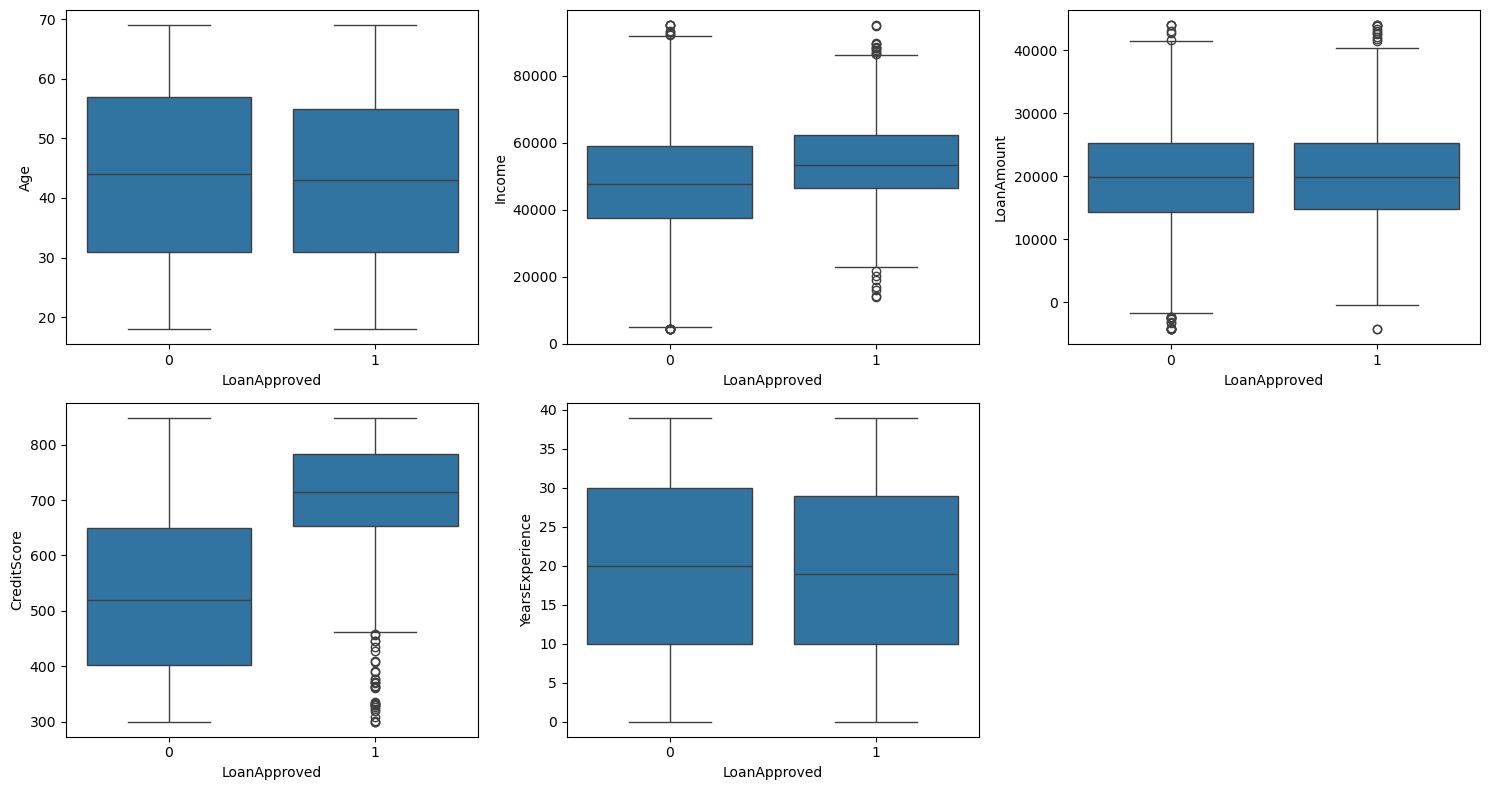

In [28]:
plt.figure(figsize=(15,8))
for i, cols in enumerate(numeric_data, 1):
    plt.subplot(2,3, i)
    sns.boxplot(x = df['LoanApproved'], y = df[cols])
plt.tight_layout()    
plt.show()

In [29]:
df['Income'] = df['Income'].fillna(df['Income'].median())

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [30]:
df['Loan_Income_Ratio'] = df['LoanAmount'] / df['Income']

In [31]:
df.sample(5)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,Loan_Income_Ratio
1218,50,44340.0,14239.0,722.0,10,Male,Masters,San Francisco,Unemployed,0,0.321132
4384,24,66773.0,28765.0,436.0,15,Female,Bachelors,Houston,Salaried,0,0.430788
3854,40,48833.0,6646.0,651.0,12,Male,NaN,Houston,Unemployed,0,0.136096
3468,64,47857.0,21986.0,667.0,19,Female,PhD,Houston,Self-Employed,1,0.459410
1911,18,64330.0,21800.0,516.0,21,Female,Bachelors,Chicago,Self-Employed,0,0.338878


## Train and Test

In [32]:
X = df.drop(['LoanApproved'], axis = 1)
y = df['LoanApproved']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
X_train

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,Loan_Income_Ratio
4227,44,49488.0,29098.0,785.0,14,Female,High School,New York,Unemployed,0.587981
4676,21,48020.0,27338.0,839.0,17,Female,Masters,Chicago,Self-Employed,0.569304
800,27,46865.0,18768.0,677.0,20,Male,High School,Chicago,Salaried,0.400469
3671,39,49488.0,13672.0,750.0,28,Female,Masters,Chicago,Unemployed,0.276269
4193,48,74681.0,22232.0,718.0,32,Female,Masters,San Francisco,Self-Employed,0.297693
...,...,...,...,...,...,...,...,...,...,...
4426,37,54400.0,28617.0,691.0,13,Male,High School,Chicago,Salaried,0.526048
466,23,67995.0,4845.0,332.0,32,Male,Bachelors,San Francisco,Self-Employed,0.071255
3092,51,31712.0,13753.0,371.0,27,Male,Bachelors,Chicago,Salaried,0.433684
3772,19,49396.0,10920.0,NaN,39,Female,NaN,Houston,Salaried,0.221071


In [35]:
numeric_data_transform = Pipeline([
    ('num_imputer', SimpleImputer(strategy='median')),
    ('scaling', StandardScaler())
])

categorical_data_transform = Pipeline([
    ('cat_imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, dtype='int32', handle_unknown='ignore'))
])

processor = ColumnTransformer([
    ('numeric', numeric_data_transform, numeric_data),
    ('categorical', categorical_data_transform, categorical_data)
])

In [36]:
print(X_train.shape)
print(X_test.shape)

(4000, 10)
(1000, 10)


In [37]:
total_negative_samples = (y_train == 0).sum()
total_positive_samples = (y_train == 1).sum()

print(total_negative_samples)
print(total_positive_samples)

3074
926


### Model

In [38]:
estimators = [
    ('rf', RandomForestClassifier(class_weight='balanced')),
    ('xgboost', XGBClassifier(scale_pos_weight = total_negative_samples / total_positive_samples))
]

In [39]:
model = StackingClassifier(
    estimators = estimators,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv = 10
)

In [40]:
final_model = Pipeline([
    ('processing', processor),
    ('model', model)
])

In [41]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('processing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder...
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))],
                                    final_estimator=LogisticRegression(class_weight='balanced')))])

In [42]:
y_pred = final_model.predict(X_test)

In [43]:
accuracy_score(y_test, y_pred)

0.964

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       775
           1       0.95      0.89      0.92       225

    accuracy                           0.96      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.96      0.96      0.96      1000



In [45]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[764  11]
 [ 25 200]]


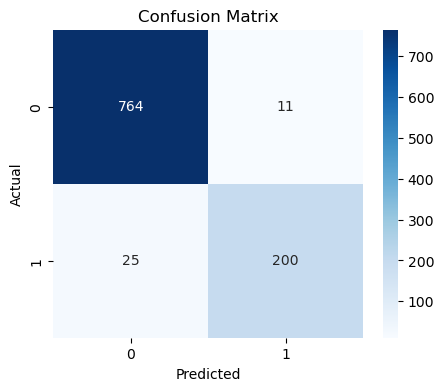

In [57]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [47]:
y_prob = final_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

In [48]:
print(auc_score)

0.9492014336917564


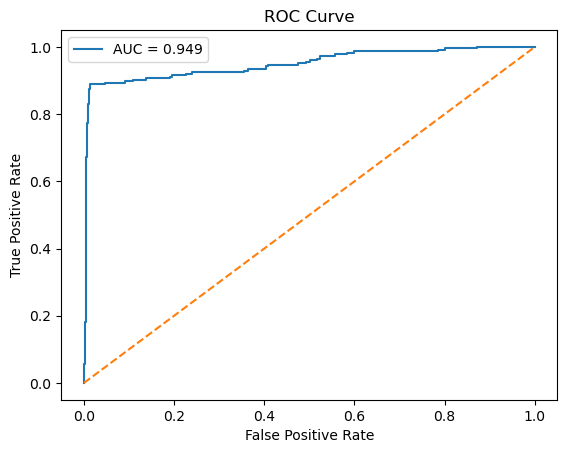

In [49]:
plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Calculating Metric For Individual

In [50]:
def evaluate1(model_name, y_test, y_pred):
    print("Accuracy  :", accuracy_score(y_test, y_pred))
    print("Precision :", precision_score(y_test, y_pred))
    print("Recall    :", recall_score(y_test, y_pred))
    print("F1 Score  :", f1_score(y_test, y_pred))
    

In [51]:
for name, model in estimators:
    print(f"\n{name.upper()}")

    temp_pipeline = Pipeline([
        ('processor', processor),
        ('model', model)
    ])


    temp_pipeline.fit(X_train, y_train)
    y_pred = temp_pipeline.predict(X_test)

    evaluate1(name, y_test, y_pred)

print()
final_model.fit(X_train, y_train)
y_pred_stack = final_model.predict(X_test)
evaluate1("Stacking", y_test, y_pred_stack)


RF
Accuracy  : 0.964
Precision : 0.9521531100478469
Recall    : 0.8844444444444445
F1 Score  : 0.9170506912442397

XGBOOST
Accuracy  : 0.964
Precision : 0.9478672985781991
Recall    : 0.8888888888888888
F1 Score  : 0.9174311926605505

Accuracy  : 0.964
Precision : 0.9478672985781991
Recall    : 0.8888888888888888
F1 Score  : 0.9174311926605505


In [52]:
for name, model in estimators:

    temp_pipeline = Pipeline([
        ('processor', processor),
        ('model', model)
    ])

    scores = cross_val_score(temp_pipeline, X_train, y_train, cv=5, scoring='f1')
    
    print(f"{name.upper()} CV Scores:", scores)
    print(f"{name.upper()} Mean F1:", scores.mean())
    print()

RF CV Scores: [0.91573034 0.92896175 0.94413408 0.94972067 0.93181818]
RF Mean F1: 0.934073003226813

XGBOOST CV Scores: [0.90807799 0.91935484 0.93820225 0.94736842 0.92917847]
XGBOOST Mean F1: 0.9284363943274494



## Model

In [53]:
# import pickle

# final = {
#     'processor_data' : processor,
#     'model_data' : final_model
# }

# pickle.dump(final,open('credit-risk-prediction.pkl', 'wb'))

In [54]:
import pickle

pickle.dump(final_model, open('credit-risk-prediction.pkl', 'wb'))